# kNN Classification & Linear Regression: Feature Effects and Regularization

A hands-on look at two classic ML algorithms: how a kNN classifier's decision boundary changes with `k`, how a kNN-driven toy agent behaves under noisy landmark data, and how Ridge/Lasso regularization handle multicollinearity when predicting diamond prices.

## Part 1: Visualizing kNN Decision Boundaries

Using the `wine` dataset built into `sklearn` (chemical measurements for three wine varieties), I'll visualize how a kNN classifier's decision boundary shifts as `k` changes. Dataset details: [sklearn docs](https://scikit-learn.org/stable/modules/generated/sklearn.datasets.load_wine.html#sklearn.datasets.load_wine), [background](https://rdrr.io/cran/rattle.data/man/wine.html).

Load the dataset and split it into a feature matrix `X` and target `y`.

In [15]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

In [2]:
from sklearn.datasets import load_wine

data = load_wine()
X = pd.DataFrame(data['data'], columns = data['feature_names'])
y = data['target']
X.head(8)

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0
5,14.20,1.76,2.45,15.2,112.0,3.27,3.39,0.34,1.97,6.75,1.05,2.85,1450.0
6,14.39,1.87,2.45,14.6,96.0,2.50,2.52,0.30,1.98,5.25,1.02,3.58,1290.0
7,14.06,2.15,2.61,17.6,121.0,2.60,2.51,0.31,1.25,5.05,1.06,3.58,1295.0


Check for missing values, and check whether any features are categorical and need one-hot encoding.

In [3]:
#X.dtypes confirms every column is numeric, so there's nothing to one-hot encode
print(X.isna().sum().sum() != 0) # False -> no missing values

False


Split into train/test sets (70/30), fixing the random seed for reproducibility.

In [4]:
from sklearn.model_selection import train_test_split
smth = np.random.seed(0)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3)

Train six kNN classifiers that differ only in the number of neighbors (1, 3, 5, 10, 15, 25), using just two features -- `alcohol` and `magnesium` -- with Euclidean distance. Scale the features with `StandardScaler` first, then compare train/test accuracy across the six values of `k`.

In [5]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn import preprocessing
normalizer = preprocessing.StandardScaler()
new_X_train = X_train[['alcohol', 'magnesium']]
new_X_train_norm = normalizer.fit_transform(new_X_train)
new_X_test = X_test[['alcohol', 'magnesium']]
new_X_test_norm = normalizer.transform(new_X_test)
neighbors = [1,3,5,10,15,25]
lst = []
print('NN','Train','Test', sep='\t')
for elem in neighbors:
    clf = KNeighborsClassifier(n_neighbors=elem)
    lst.append(clf.fit(new_X_train_norm, y_train))
    y_predicted_train = clf.predict(new_X_train_norm)
    y_predicted_test = clf.predict(new_X_test_norm)
    ans_train = np.mean(y_train==y_predicted_train)
    ans_test = np.mean(y_test==y_predicted_test)
    print(elem, round(ans_train,2), round(ans_test,2), sep='\t')

NN	Train	Test
1	1.0	0.67
3	0.81	0.78
5	0.75	0.72
10	0.73	0.78
15	0.73	0.8
25	0.67	0.8


Install `mlxtend`, which I'll use to plot decision regions.

In [6]:
!pip install mlxtend

In [7]:
import mlxtend

Plot the decision regions for all six classifiers together, in a grid, using `mlxtend.plotting.plot_decision_regions`.

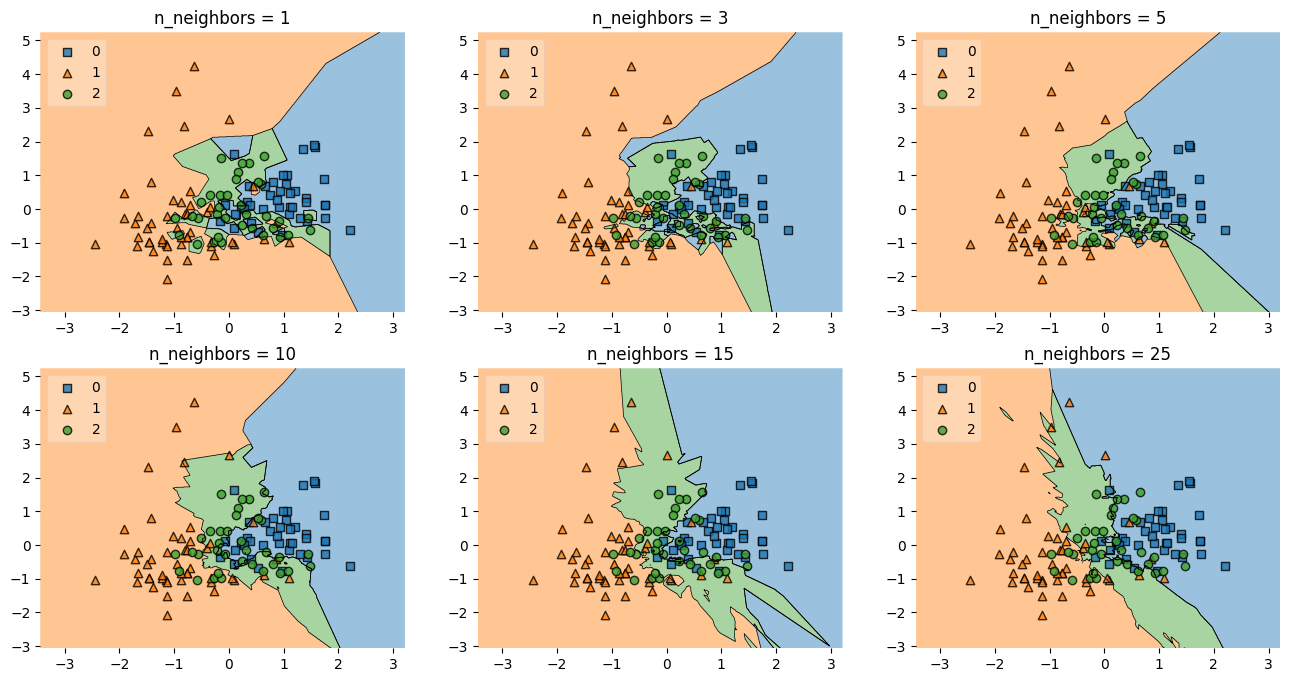

In [8]:
#adapted from the mlxtend docs example
from mlxtend.plotting import plot_decision_regions
import matplotlib.gridspec as gridspec
import itertools
gs = gridspec.GridSpec(2, 3)

fig = plt.figure(figsize=(16,8))

labels = ['n_neighbors = 1', 'n_neighbors = 3', 'n_neighbors = 5', 'n_neighbors = 10', 'n_neighbors = 15','n_neighbors = 25']
for clf, lab, grd in zip(lst,
                         labels,
                         itertools.product([0, 1],[0,1,2], repeat=1)):

    clf.fit(new_X_train_norm, y_train)
    ax = plt.subplot(gs[grd[0], grd[1]])
    fig = plot_decision_regions(X=new_X_train_norm, y=y_train, clf=clf, legend=2)
    plt.title(lab)

plt.show()


### Observations: how does `k` affect the decision boundary?

n_neighbors=25 gives the best test accuracy, and even though its boundary isn't perfectly smooth, it stays reasonably simple rather than overfitting to noise.
Looking at the boundaries, the label space might really be two classes rather than three -- class 2 blends into either class 0 or class 1 depending on the region.

## Part 2: A Learned Robot -- kNN-Guided Movement

A simplified model of using k-nearest neighbors to guide a robot's movement.

The robot lives on a discrete 2D grid and can move one step right, left, up, or down at each time step. Landmarks scattered across the plane belong to one of four classes, which the robot can use to adjust its direction: class 0 -> move right, class 1 -> move left, class 2 -> move up, class 3 -> move down.

Movement rule: with probability 0.2 the robot moves right regardless; otherwise (probability 0.8) it checks the majority class among its `k` nearest landmark neighbors and moves in that direction.

Here's an example layout of the robot and the landmarks:

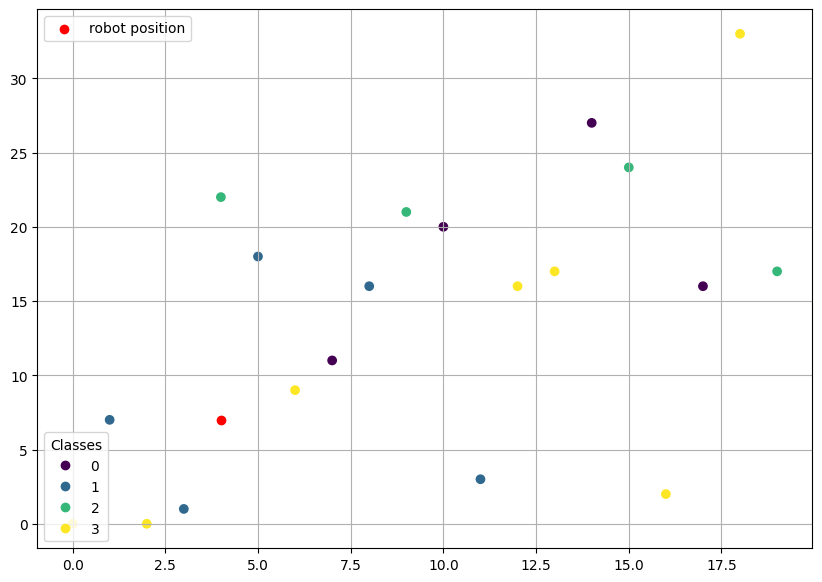

In [9]:
np.random.seed(12345)
x = np.arange(20)
landmarks = x + np.round(np.random.normal(2, 8, 20)) # generate random landmark positions
random_classes = np.random.randint(0, 4, 20)

fig, ax = plt.subplots(figsize = (10, 7))
scatter = ax.scatter(x, landmarks, c = random_classes)
ax.scatter(4, 7, c = 'r', marker = 'o', label = 'robot position')
legend1 = ax.legend(*scatter.legend_elements(),
                    loc = "lower left", title = "Classes")
ax.add_artist(legend1)

plt.plot()
_ = plt.legend()
_ = plt.grid()

Next, the robot takes a step -- either right, or in the direction its nearest neighbors point to.

Implement a `MobileRobot` class:
1. `trajectory` holds the history of the robot's positions; `knn` is a fitted kNN classifier that predicts a landmark's class from its position.
2. `move()` computes the next position following the rule above and appends it to `trajectory` (the 0.2/0.8 split can be modeled as a coin flip via `np.random.binomial`).

In [10]:
from sklearn.neighbors import KNeighborsClassifier

In [11]:
class MobileRobot():

    def __init__(self, k, initial_position, landmarks, classes):
        '''
        Attributes:
        ------
        k: int
            Number of neighbours

        initial_position: ndarray
            Initial position of the robot as a point, e.g. (-1, 1)

        landmarks: ndarray
            numpy array of shape (n_landmarks, 2) with the euclidean positions of points

        classes: ndarray
            numpy array of shape (n_landmarks, ) with class of landmark for each point in landmarks

        '''
        # Store the history of movements
        self.trajectory =  np.array([initial_position])

        # kNN Classifier for determining the classes of landmarks
        self.knn = KNeighborsClassifier(n_neighbors=k).fit(landmarks, classes)
        # Mapping between classes of points and movements
        self.mapping = {0: np.array([1, 0]),
                        1: np.array([-1, 0]),
                        2: np.array([0, 1]),
                        3: np.array([0, -1])}

    def move(self):
        '''
        Calculate new position of the robot and add it to the history
        '''
        smth = np.random.binomial(1,p=0.2)
        new_position =self.mapping[int(self.knn.predict(np.array([self.trajectory[-1]])))] * (1 - smth) + self.trajectory[-1] + smth * np.array([1, 0])
        self.trajectory =np.append(self.trajectory,np.array([new_position]), axis = 0)




Fill in `conduct_experiment`: build `traj`, a 2D numpy array of the robot's movement history where the columns are the x and y coordinates.

In [12]:
def conduct_experiment(x,
                       mean = 0,
                       std = 2,
                       n_movements = 10,
                       k = 3,
                       initial_position = np.array([10, 20])):

    np.random.seed(12345)
    # Generate random landmarks
    landmarks = np.vstack((x, x + np.round(np.random.normal(mean, std, len(x))))).T

    # Generate random classes of landmarks
    classes = np.random.randint(0, 4, size = len(x))

    # Conduct experiment
    robot = MobileRobot(k, initial_position, landmarks, classes)

    for n in range(n_movements):
        robot.move()

    fig, ax = plt.subplots(figsize = (10, 8))
    scatter = ax.scatter(landmarks[:, 0], landmarks[:, 1], c = classes)
    legend1 = ax.legend(*scatter.legend_elements(),
                        loc="lower left", title="classes")
    ax.add_artist(legend1)

    traj = robot.trajectory
    ax.plot(traj[:, 0], traj[:, 1],
               c = 'r', marker = 'o', label = 'robot position')

    plt.plot()
    _ = plt.legend()
    _ = plt.grid()

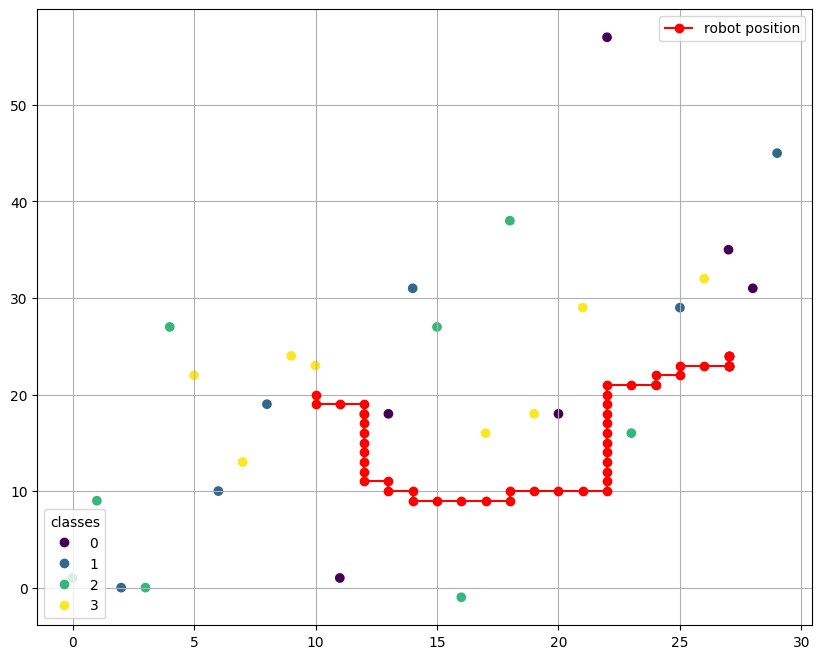

In [16]:
x = np.arange(30)
conduct_experiment(x, mean = 3, std = 10, k = 5, n_movements = 50)

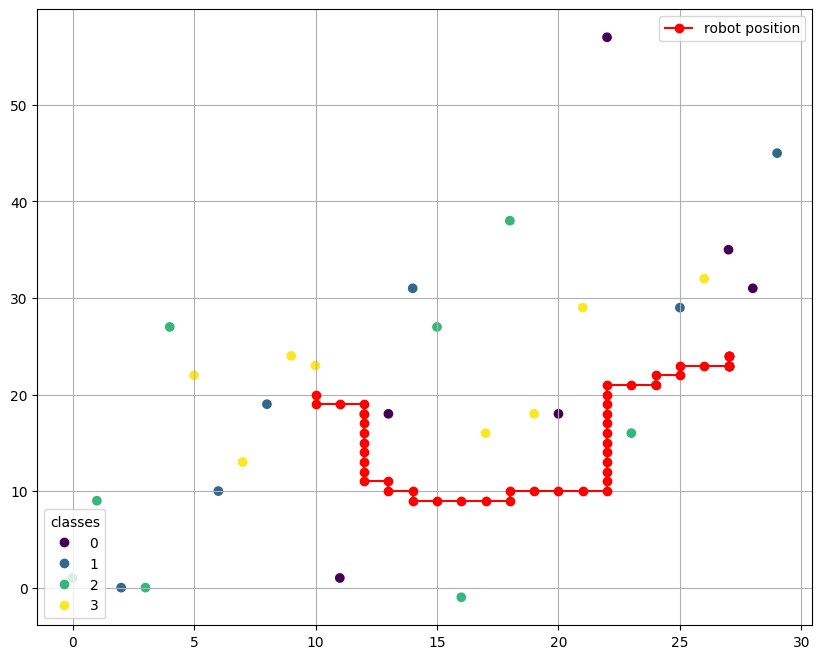

In [17]:
x = np.arange(30)
conduct_experiment(x, mean = 3, std = 10, k = 5, n_movements = 50)

### How does the number of neighbors affect the robot's trajectory?

Plotting four runs below with different values of `k`. If landmark classes were assigned meaningfully instead of randomly, the robot's path could be steered on purpose rather than by chance -- see the note in the code cell.

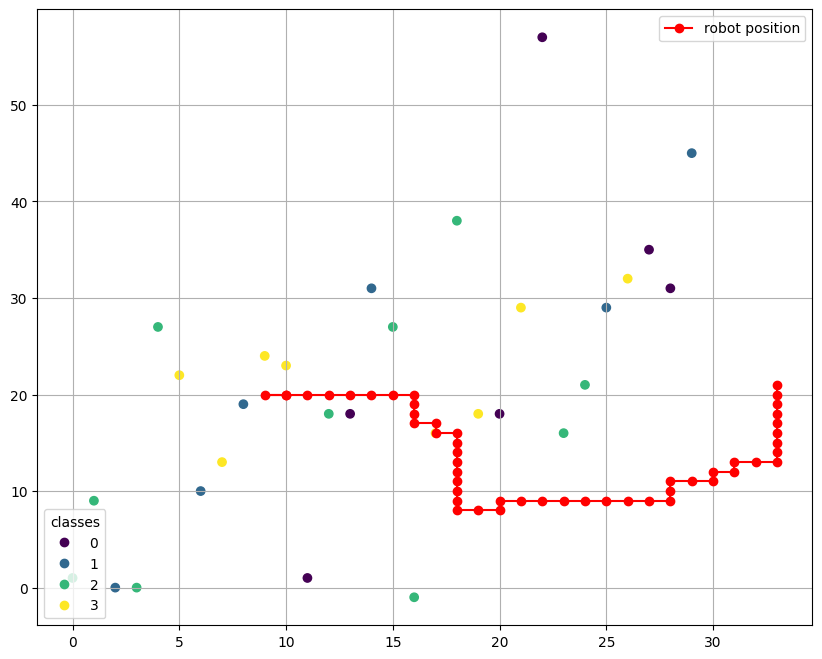

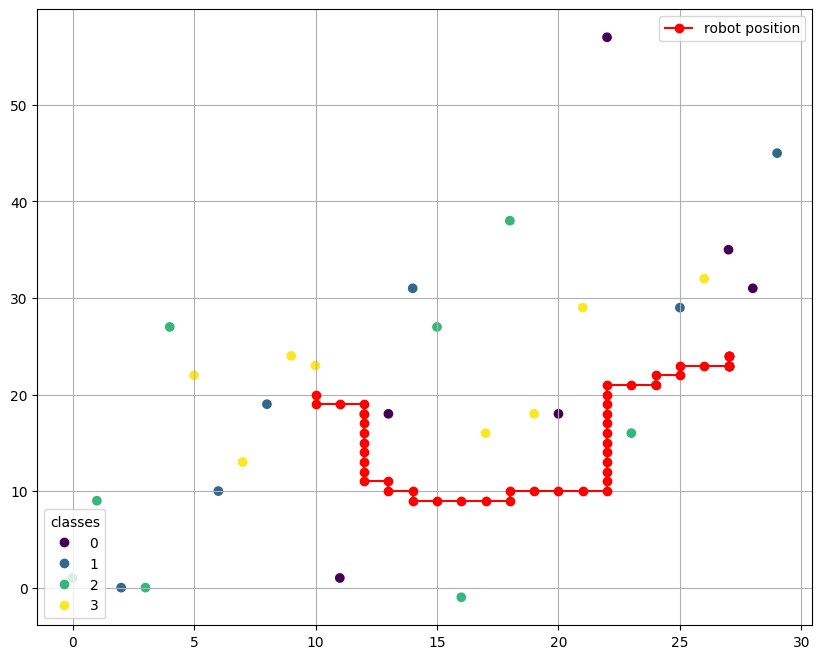

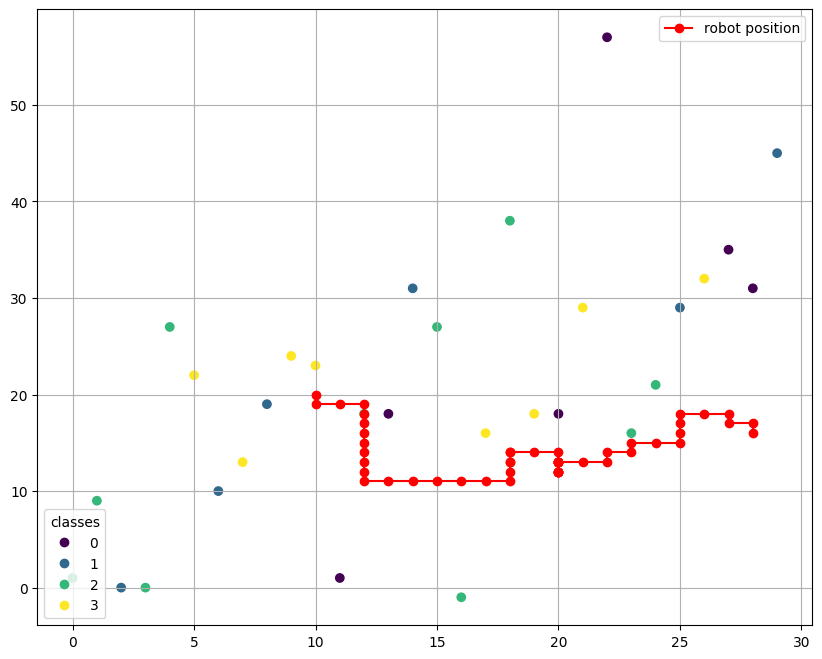

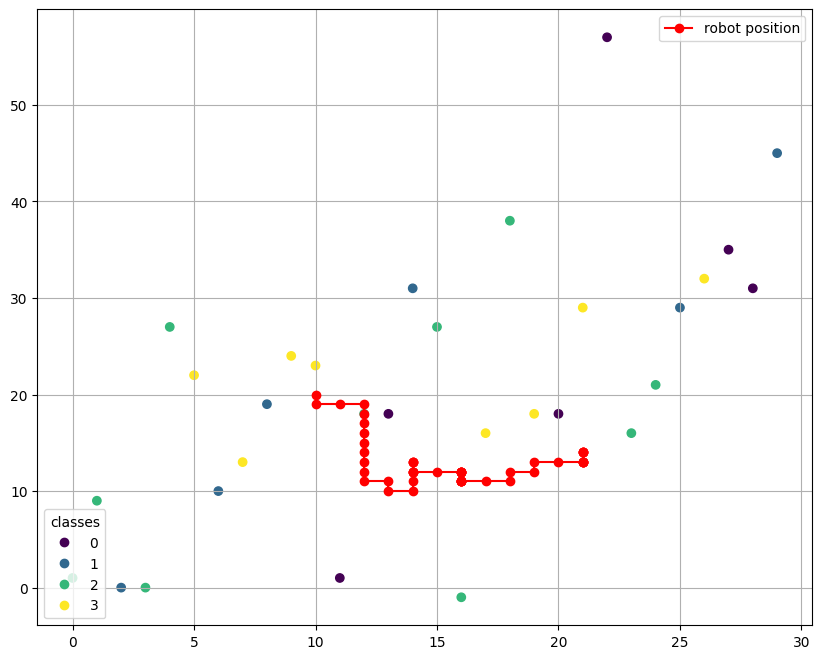

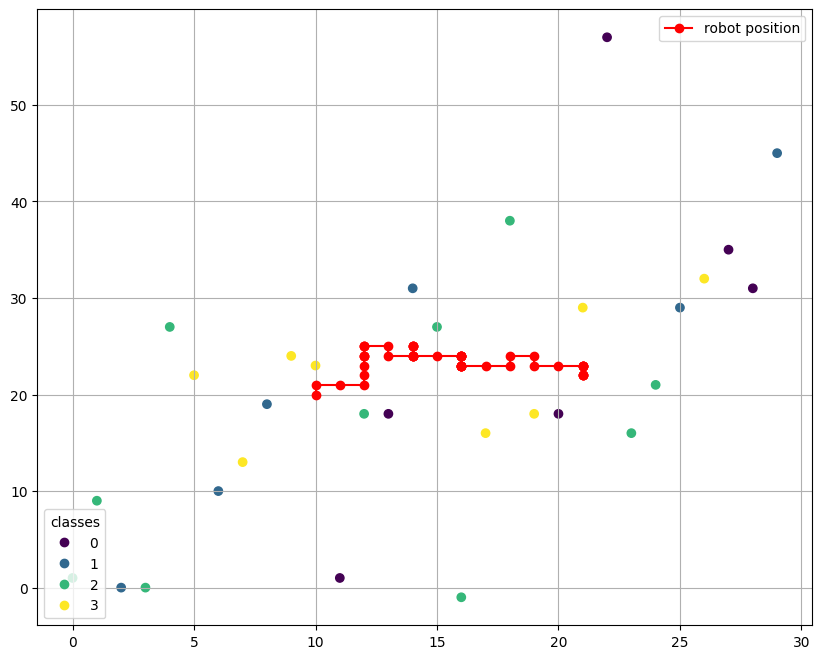

In [18]:
conduct_experiment(x, mean = 3, std = 10, k = 3, n_movements = 50)
conduct_experiment(x, mean = 3, std = 10, k = 5, n_movements = 50)
conduct_experiment(x, mean = 3, std = 10, k = 10, n_movements = 50)
conduct_experiment(x, mean = 3, std = 10, k = 15, n_movements = 50)
conduct_experiment(x, mean = 3, std = 10, k = 25, n_movements = 50)
# If landmark classes were assigned meaningfully rather than randomly, I could roughly steer the robot's
# direction on purpose -- 'roughly' because there's still a 20% chance of a forced rightward step regardless
# of what the neighbors say.

## Part 3: Linear Regression -- Diamond Prices

Working with a classic dataset: diamond characteristics and prices ([source](https://www.kaggle.com/shivam2503/diamonds)). Goal: predict `price` from the diamond's other attributes.

In [22]:
data = pd.read_csv('https://raw.githubusercontent.com/hse-ds/iad-intro-ds/master/2021/homeworks/hw04-knn_linreg/data/diamonds.csv')
data.head()

,Unnamed: 0,carat,cut,color,clarity,depth,table,price,x,y,z
0,1,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,2,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,3,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,4,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,5,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75


Check for missing values and drop them if any are present.

In [20]:
#data.dtypes shows every column except three is numeric
print(data.isnull().sum().sum() != 0) # False -> no missing values among the numeric columns
#also checked data['clarity'].unique(), data['cut'].unique(), data['color'].unique() -- no missing values there either

False


Drop any columns that don't carry real information.

In [26]:
data = data.drop('Unnamed: 0', axis=1)

Linear regression assumes a roughly linear relationship between features and the target, so it's worth checking sample correlations before deciding which features to include -- this will also be useful later when discussing multicollinearity. Compute the correlation matrix across all numeric features and the target.

Which numeric features correlate most strongly with `price`?

In [27]:
lst_num = np.array([])
lst_obj = np.array([])
for elem in data.columns:
    if data[elem].dtype=='int64' or data[elem].dtype=='float64':
        lst_num = np.append(lst_num, elem)
    else:
        lst_obj = np.append(lst_obj, elem)
dt = data[lst_num]
matr_corr = dt.corr()
matr_corr
# carat, x, y, and z correlate with price the most

,carat,depth,table,price,x,y,z
carat,1.000000,0.028224,0.181618,0.921591,0.975094,0.951722,0.953387
depth,0.028224,1.000000,-0.295779,-0.010647,-0.025289,-0.029341,0.094924
table,0.181618,-0.295779,1.000000,0.127134,0.195344,0.183760,0.150929
price,0.921591,-0.010647,0.127134,1.000000,0.884435,0.865421,0.861249
x,0.975094,-0.025289,0.195344,0.884435,1.000000,0.974701,0.970772
y,0.951722,-0.029341,0.183760,0.865421,0.974701,1.000000,0.952006
z,0.953387,0.094924,0.150929,0.861249,0.970772,0.952006,1.000000


One-hot encode the categorical features, since a linear model just sums weighted feature values and can't work with raw categories.

In [28]:
dt = pd.get_dummies(data)
dt

,carat,depth,table,price,x,y,z,cut_Fair,cut_Good,cut_Ideal,...,color_I,color_J,clarity_I1,clarity_IF,clarity_SI1,clarity_SI2,clarity_VS1,clarity_VS2,clarity_VVS1,clarity_VVS2
0,0.23,61.5,55.0,326,3.95,3.98,2.43,False,False,True,...,False,False,False,False,False,True,False,False,False,False
1,0.21,59.8,61.0,326,3.89,3.84,2.31,False,False,False,...,False,False,False,False,True,False,False,False,False,False
2,0.23,56.9,65.0,327,4.05,4.07,2.31,False,True,False,...,False,False,False,False,False,False,True,False,False,False
3,0.29,62.4,58.0,334,4.20,4.23,2.63,False,False,False,...,True,False,False,False,False,False,False,True,False,False
4,0.31,63.3,58.0,335,4.34,4.35,2.75,False,True,False,...,False,True,False,False,False,True,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
53935,0.72,60.8,57.0,2757,5.75,5.76,3.50,False,False,True,...,False,False,False,False,True,False,False,False,False,False
53936,0.72,63.1,55.0,2757,5.69,5.75,3.61,False,True,False,...,False,False,False,False,True,False,False,False,False,False
53937,0.70,62.8,60.0,2757,5.66,5.68,3.56,False,False,False,...,False,False,False,False,True,False,False,False,False,False
53938,0.86,61.0,58.0,2757,6.15,6.12,3.74,False,False,False,...,False,False,False,False,False,True,False,False,False,False


Split into train/test sets (70/30).

In [30]:
smth = np.random.seed(0)
dt1 = dt.drop('price', axis=1)
X = pd.DataFrame(dt, columns = dt1.columns)
y = dt['price']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3)
X

,carat,depth,table,x,y,z,cut_Fair,cut_Good,cut_Ideal,cut_Premium,...,color_I,color_J,clarity_I1,clarity_IF,clarity_SI1,clarity_SI2,clarity_VS1,clarity_VS2,clarity_VVS1,clarity_VVS2
0,0.23,61.5,55.0,3.95,3.98,2.43,False,False,True,False,...,False,False,False,False,False,True,False,False,False,False
1,0.21,59.8,61.0,3.89,3.84,2.31,False,False,False,True,...,False,False,False,False,True,False,False,False,False,False
2,0.23,56.9,65.0,4.05,4.07,2.31,False,True,False,False,...,False,False,False,False,False,False,True,False,False,False
3,0.29,62.4,58.0,4.20,4.23,2.63,False,False,False,True,...,True,False,False,False,False,False,False,True,False,False
4,0.31,63.3,58.0,4.34,4.35,2.75,False,True,False,False,...,False,True,False,False,False,True,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
53935,0.72,60.8,57.0,5.75,5.76,3.50,False,False,True,False,...,False,False,False,False,True,False,False,False,False,False
53936,0.72,63.1,55.0,5.69,5.75,3.61,False,True,False,False,...,False,False,False,False,True,False,False,False,False,False
53937,0.70,62.8,60.0,5.66,5.68,3.56,False,False,False,False,...,False,False,False,False,True,False,False,False,False,False
53938,0.86,61.0,58.0,6.15,6.12,3.74,False,False,False,True,...,False,False,False,False,False,True,False,False,False,False


Scaling numeric features is common practice for linear models -- it costs the direct statistical interpretation of coefficients ("a 1-unit increase in $X_1$ raises $y$ by $w_1$"), but makes the model better-behaved for downstream ML use, e.g. comparing coefficient magnitudes across features. Scale the numeric features with `StandardScaler`.

In [31]:
normalizer = preprocessing.StandardScaler()
X_train_norm = normalizer.fit_transform(X_train)
X_test_norm = normalizer.transform(X_test)

Fit a linear regression on the training set and check MSE on both train and test.

In [33]:
from sklearn.linear_model import LinearRegression
lr = LinearRegression()
lr.fit(X_train_norm, y_train)
y_pred_train = lr.predict(X_train_norm)
y_pred_test = lr.predict(X_test_norm)
print(np.mean(np.square(y_train- y_pred_train)))
print(np.mean(np.square(y_test- y_pred_test)))


1284661.862119126
1259159.1137946646


Look at the fitted coefficients -- which real-valued features have coefficients an order of magnitude larger than the rest?

In [34]:
coefs = lr.coef_
coefs
# the one-hot encoded categorical variables end up with disproportionately large coefficient estimates

array([ 5.27811998e+03, -9.42669361e+01, -6.56183723e+01, -1.05002476e+03,
       -2.64737971e+00, -4.05686230e+01, -1.17657475e+02, -4.29468690e+01,
        5.14327290e+01,  1.34924673e+01,  3.16980591e+00,  1.98666784e+02,
        1.60828520e+02,  1.38644469e+02,  5.98261366e+01, -1.24320055e+02,
       -2.50445153e+02, -3.85587906e+02, -4.74518068e+02,  2.36734797e+02,
       -1.47687171e+02, -4.93878104e+02,  2.06290798e+02,  1.07979965e+02,
        2.53249672e+02,  2.74141081e+02])

The correlation matrix above showed strong correlation between some features, which is a sign of multicollinearity -- and the coefficient-magnitude differences from the last step back that up. Rather than dropping features, I'll address it with regularization.

L1 regularization (**Lasso**) minimizes:

$$
\|y - X\hat{w}\|^2 + \alpha\sum_{i=1}^k|w_i|
$$

L2 regularization (**Ridge**) minimizes:

$$
\|y - X\hat{w}\|^2 + \frac{1}{2}\alpha\|w\|^2
$$

Fit both with `alpha=10` and compare how much the weights shrink -- that's a good indicator of how badly multicollinearity was affecting the original regression.

In [35]:
from sklearn import linear_model
reg_r = linear_model.Ridge(alpha=10)
reg_r.fit(X_train_norm, y_train)
y_pred_train_r = reg_r.predict(X_train_norm)
y_pred_test_r = reg_r.predict(X_test_norm)
coef_r = reg_r.coef_

reg_l = linear_model.Lasso(alpha=10)
reg_l.fit(X_train_norm, y_train)
y_pred_train_l = reg_l.predict(X_train_norm)
y_pred_test_l = reg_l.predict(X_test_norm)
coef_l = reg_l.coef_
# weights shrank by roughly a factor of 10^6 -- multicollinearity was clearly a serious problem in the
# unregularized model

Lasso regression can double as feature selection. For alpha in [0.1, 1, 10, 100, 200], fit both Lasso and Ridge and plot how the L2 norm of the weight vector (`np.linalg.norm()`) changes with alpha -- the norm is a quick summary of how large the coefficient vector's entries are overall.

Which method shrinks weights more aggressively, and why does that make Lasso a natural fit for feature selection?

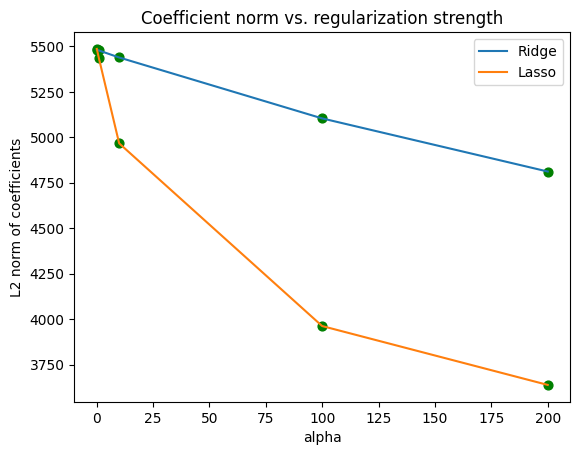

In [36]:
alphas = np.array([0.1, 1, 10, 100, 200])
norm1 = np.array([])
norm2 = np.array([])
for elem in alphas:
    reg1 = linear_model.Ridge(alpha=elem)
    reg2 = linear_model.Lasso(alpha=elem)
    reg1.fit(X_train_norm, y_train)
    reg2.fit(X_train_norm, y_train)
    coef1 = np.linalg.norm(reg1.coef_)
    coef2 = np.linalg.norm(reg2.coef_)
    norm1 = np.append(norm1, coef1)
    norm2 = np.append(norm2, coef2)
plt.plot(alphas, norm1, label = 'Ridge')
plt.plot(alphas, norm2, label = 'Lasso')
plt.scatter(alphas, norm1, color='green', s=40, marker='o')
plt.scatter(alphas, norm2, color='green', s=40, marker='o')
plt.title('Coefficient norm vs. regularization strength')
plt.xlabel('alpha')
plt.ylabel('L2 norm of coefficients')
plt.legend()
# Lasso shrinks weights much more aggressively as alpha grows -- it tends to zero out coefficients entirely,
# which is exactly why it doubles as a feature-selection tool.
# Lasso relies on coefficient shrinkage -- pulling coefficient values toward a central point (e.g. zero) --
# rather than the smooth, gradual downweighting Ridge does.
# reference: https://habr.com/ru/company/vk/blog/513842/

Lasso zeroes out different coefficients depending on alpha. To pick a good value, I'll cross-validate with `LassoCV`, which tries each alpha in the given list, runs k-fold CV (`cv=5`), and stores per-fold MSE in `.mse_path_` (shape `len(alphas) x cv`). Note that `LassoCV` may reorder the alphas internally -- `.alphas_` gives the order actually used.

Average the MSE across folds for each alpha and pick whichever gives the lowest error.

In [39]:
from sklearn.linear_model import LassoCV
lcv = LassoCV(cv=5,alphas=alphas).fit(X_train_norm, y_train)
matr_mse = lcv.mse_path_
ideal_a = alphas[np.argmin(matr_mse.mean(axis=1))]
ideal_a

np.float64(100.0)

Fit the final Lasso model with the chosen alpha, inspect the coefficients, and see which features turned out uninformative vs. most informative -- with a plausible explanation for why.

In [40]:
reg = linear_model.Lasso(alpha=ideal_a)
reg.fit(X_train_norm, y_train)
print(reg.coef_)
X.columns

[ 3.89125642e+03 -0.00000000e+00 -0.00000000e+00  0.00000000e+00
  0.00000000e+00  0.00000000e+00 -6.75317506e+01 -0.00000000e+00
  2.14508985e+01 -0.00000000e+00 -0.00000000e+00  1.29052069e-01
  0.00000000e+00  0.00000000e+00  0.00000000e+00 -8.37043088e+01
 -1.63218413e+02 -2.80731272e+02 -3.93281036e+02  7.26763266e+01
 -2.08569335e+02 -4.69197211e+02  0.00000000e+00 -0.00000000e+00
  6.91934406e+01  8.96597591e+01]


Index(['carat', 'depth', 'table', 'x', 'y', 'z', 'cut_Fair', 'cut_Good',
       'cut_Ideal', 'cut_Premium', 'cut_Very Good', 'color_D', 'color_E',
       'color_F', 'color_G', 'color_H', 'color_I', 'color_J', 'clarity_I1',
       'clarity_IF', 'clarity_SI1', 'clarity_SI2', 'clarity_VS1',
       'clarity_VS2', 'clarity_VVS1', 'clarity_VVS2'],
      dtype='object')

Carat turns out to be by far the most informative feature -- it has the largest weight.
The other raw numeric features (depth, table, x, y, z) get zeroed out -- probably because size/shape alone doesn't guarantee a stone is gem-quality once carat is already accounted for.
Most of the 'cut' categories get zeroed out too, which makes sense: no amount of cutting turns a low-quality stone into a diamond that commands a premium.
Among the color categories, only the worst ones seem to matter, and negatively -- likely because those lower grades are common enough that the signal is reliable, while better colors don't reliably predict a higher price on their own.
Clarity contributes more: I1 (worst grade) is strongly negative and IF (best grade) is strongly positive, and most other clarity levels keep a nonzero weight -- worse grades pull the coefficient negative, better grades pull it positive.

Compare Lasso's test-set MSE against the plain linear regression's. Which model generalizes better here, and why?

In [41]:
print('Lasso:',np.mean(np.square(y_test- reg.predict(X_test_norm))))
print('MSE:', np.mean(np.square(y_test- y_pred_test)))

Lasso: 1528321.4171096275
MSE: 1259159.1137946646


Lasso actually does worse than plain linear regression on this test set.
The unregularized model fit the training data more closely and kept every feature, including the low-importance ones, which apparently still carried some predictive signal.
So on the held-out test set, Lasso's aggressive shrinkage ends up costing it accuracy.  Lasso is still useful for surfacing the most important features -- it just turns out some of what it zeroed out wasn't as useless for prediction as it looked. For raw predictive accuracy here, plain linear regression (lower test MSE) wins.